In [ ]:
#Cell 1 — Upload dataset
from google.colab import files
uploaded = files.upload()  # select wifi_bandwidth_campus_v3.csv when prompted

Saving wifi_bandwidth_campus_v3.csv to wifi_bandwidth_campus_v3 (1).csv


In [ ]:
#Cell 2 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

np.random.seed(42)

In [ ]:
#Cell 3 — Load & inspect data
df = pd.read_csv("wifi_bandwidth_campus_v3.csv")
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Hour"] = df["Time_Slot"].str.split("-").str[0].str.split(":").str[0].astype(int)
df["DateTime"] = df["Date"] + pd.to_timedelta(df["Hour"], unit="h")
df = df.sort_values(["Location", "DateTime"]).reset_index(drop=True)

print(df.shape)
print(df["Location"].unique())
df.head()

(10044, 15)
['Admin Block' 'Auditorium' 'Canteen/Mess' 'Classroom Block'
 'Hostel Block A' 'Hostel Block B' 'Library' 'Open Campus/Quad'
 'Sports Ground']


,Date,Day,Time_Slot,Environment,Location,Connected_Devices,Download_Mbps_per_Device,Upload_Mbps_per_Device,Aggregate_Download_Mbps,Latency_ms,Signal_Strength_dBm,Dominant_Protocol,Packet_Loss_Percent,Hour,DateTime
0,2024-01-01,Monday,00:00-02:00,Administrative,Admin Block,4,5.35,1.79,21.47,24.3,-54.8,Gaming,0.50,0,2024-01-01 00:00:00
1,2024-01-01,Monday,02:00-04:00,Administrative,Admin Block,7,4.73,1.03,33.34,19.8,-53.8,Gaming,0.54,2,2024-01-01 02:00:00
2,2024-01-01,Monday,04:00-06:00,Administrative,Admin Block,4,5.17,1.52,20.77,15.8,-52.7,HTTP/HTTPS,0.54,4,2024-01-01 04:00:00
3,2024-01-01,Monday,06:00-08:00,Administrative,Admin Block,4,5.09,1.45,20.42,9.6,-53.3,Gaming,0.53,6,2024-01-01 06:00:00
4,2024-01-01,Monday,08:00-10:00,Administrative,Admin Block,40,2.46,0.81,101.89,80.3,-52.5,Video Streaming,0.93,8,2024-01-01 08:00:00


In [ ]:
#Cell 4 — Choose location & target
TARGET_LOCATION = "Canteen/Mess"          # change to any location
TARGET_COL = "Aggregate_Download_Mbps"    # or "Download_Mbps_per_Device"

loc_df = df[df["Location"] == TARGET_LOCATION].copy().reset_index(drop=True)
print(f"Rows for {TARGET_LOCATION}: {len(loc_df)}")

Rows for Canteen/Mess: 1116


In [ ]:
#Cell 5 — Feature engineering
loc_df["hour_sin"] = np.sin(2 * np.pi * loc_df["Hour"] / 24)
loc_df["hour_cos"] = np.cos(2 * np.pi * loc_df["Hour"] / 24)
loc_df["dow"] = loc_df["DateTime"].dt.dayofweek
loc_df["dow_sin"] = np.sin(2 * np.pi * loc_df["dow"] / 7)
loc_df["dow_cos"] = np.cos(2 * np.pi * loc_df["dow"] / 7)
loc_df["is_weekend"] = (loc_df["dow"] >= 5).astype(int)

feature_cols = [
    TARGET_COL, "Connected_Devices", "Latency_ms", "Signal_Strength_dBm",
    "Packet_Loss_Percent", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
]
data = loc_df[feature_cols].values

In [ ]:
#Cell 6 — Scale & create sliding-window sequences
SEQ_LEN = 12          # last 12 slots (24 hours) predicts the next slot
TRAIN_FRACTION = 0.8

split_idx = int(len(data) * TRAIN_FRACTION)
train_raw, test_raw = data[:split_idx], data[split_idx:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

def make_sequences(arr, seq_len, target_idx=0):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i:i + seq_len])
        y.append(arr[i + seq_len, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, SEQ_LEN)
X_test, y_test = make_sequences(test_scaled, SEQ_LEN)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (880, 12, 10) Test: (212, 12, 10)


In [ ]:
#Cell 7 — Build LSTM model
n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, n_features),
         kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    LSTM(32, kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1469 - mae: 0.2894 - val_loss: 0.1268 - val_mae: 0.2991
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1258 - mae: 0.2897 - val_loss: 0.1196 - val_mae: 0.2413
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1164 - mae: 0.2584 - val_loss: 0.0993 - val_mae: 0.2402
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1034 - mae: 0.2455 - val_loss: 0.0957 - val_mae: 0.2375
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0861 - mae: 0.2206 - val_loss: 0.0627 - val_mae: 0.1708
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0481 - mae: 0.1462 - val_loss: 0.0289 - val_mae: 0.0923
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0331 - mae: 0.1033 - val_loss: 0.0162 - val_mae: 0.0595
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0236 - mae: 0.0853 - val_loss: 0.0138 - val_mae: 0.0512
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

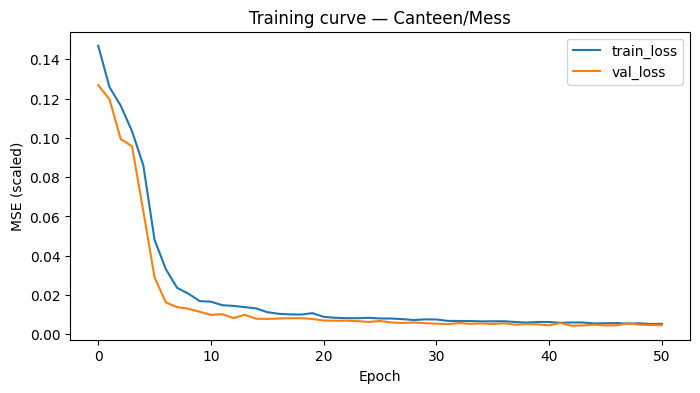

In [ ]:
#Cell 8 — Train
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title(f"Training curve — {TARGET_LOCATION}")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)"); plt.legend()
plt.show()

In [ ]:
#Cell 9 — Predict & inverse-transform
y_pred_scaled = model.predict(X_test).flatten()

def inverse_target(scaled_values, scaler, target_idx, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_test_real = inverse_target(y_test, scaler, 0, n_features)
y_pred_real = inverse_target(y_pred_scaled, scaler, 0, n_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [ ]:
#Cell 10 — Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / np.clip(y_test_real, 1e-3, None))) * 100

print(f"RMSE : {rmse:.2f} Mbps")
print(f"MAE  : {mae:.2f} Mbps")
print(f"MAPE : {mape:.2f}%")

RMSE : 16.44 Mbps
MAE  : 12.61 Mbps
MAPE : 10.72%


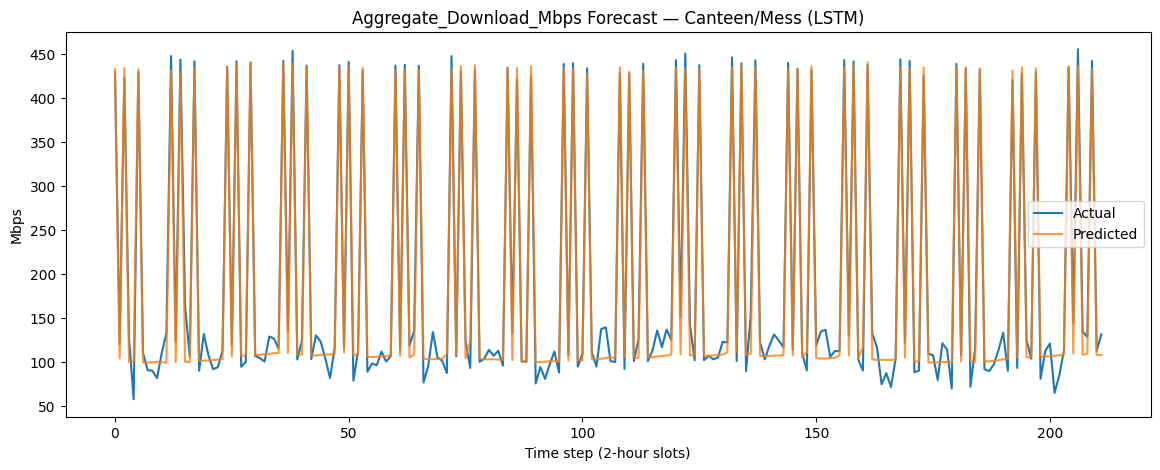

In [ ]:
#Cell 11 — Plot predicted vs actual
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, label="Actual", linewidth=1.5)
plt.plot(y_pred_real, label="Predicted", linewidth=1.5, alpha=0.8)
plt.title(f"{TARGET_COL} Forecast — {TARGET_LOCATION} (LSTM)")
plt.xlabel("Time step (2-hour slots)")
plt.ylabel("Mbps")
plt.legend()
plt.show()

In [ ]:
#Cell 12 — Forecast the next slot
last_window = test_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, n_features)
next_scaled = model.predict(last_window).flatten()
next_real = inverse_target(next_scaled, scaler, 0, n_features)
print(f"Predicted next-slot {TARGET_COL} for {TARGET_LOCATION}: {next_real[0]:.2f} Mbps")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted next-slot Aggregate_Download_Mbps for Canteen/Mess: 108.16 Mbps


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 13 — Model Accuracy Summary (Canteen/Mess — current model)
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics import r2_score

r2 = r2_score(y_test_real, y_pred_real)

# Accuracy as (100 - MAPE) — standard way to express it
accuracy = max(0, 100 - mape)

print("=" * 50)
print(f"  LSTM Model Accuracy — {TARGET_LOCATION}")
print("=" * 50)
print(f"  RMSE     : {rmse:.2f} Mbps")
print(f"  MAE      : {mae:.2f} Mbps")
print(f"  MAPE     : {mape:.2f} %")
print(f"  R² Score : {r2:.4f}  (1.0 = perfect)")
print(f"  Accuracy : {accuracy:.2f} %  (= 100 - MAPE)")
print("=" * 50)

# Visual accuracy bar
bar_len = 40
filled  = int(accuracy / 100 * bar_len)
bar     = "█" * filled + "░" * (bar_len - filled)
print(f"\n  [{bar}] {accuracy:.1f}%")


  LSTM Model Accuracy — Canteen/Mess
  RMSE     : 16.44 Mbps
  MAE      : 12.61 Mbps
  MAPE     : 10.72 %
  R² Score : 0.9870  (1.0 = perfect)
  Accuracy : 89.28 %  (= 100 - MAPE)

  [███████████████████████████████████░░░░░] 89.3%


In [ ]:

# ─────────────────────────────────────────────────────────────────
# Cell 14 — Run All 9 Locations & Build Comparison Table
# ─────────────────────────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np, pandas as pd

# ── helpers (same as your existing cells) ──────────────────────
def make_sequences(arr, seq_len, target_idx=0):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i : i + seq_len])
        y.append(arr[i + seq_len, target_idx])
    return np.array(X), np.array(y)

def inverse_target(scaled_values, scaler, target_idx, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, target_idx]

def build_lstm(seq_len, n_features):
    m = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(seq_len, n_features),
             kernel_regularizer=l2(1e-4)),
        Dropout(0.2),
        LSTM(32, kernel_regularizer=l2(1e-4)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return m

# ── config ─────────────────────────────────────────────────────
SEQ_LEN        = 12
TRAIN_FRACTION = 0.8
TARGET_COL     = "Aggregate_Download_Mbps"

feature_cols_base = [
    TARGET_COL, "Connected_Devices", "Latency_ms",
    "Signal_Strength_dBm", "Packet_Loss_Percent",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
]

locations   = df["Location"].unique()
all_results = []

print("🚀 Training LSTM for all 9 locations ...\n")

for loc in locations:
    print(f"▶  {loc}")

    # ── filter & feature-engineer ──────────────────────────────
    loc_df = df[df["Location"] == loc].copy().reset_index(drop=True)
    loc_df["hour_sin"]   = np.sin(2 * np.pi * loc_df["Hour"] / 24)
    loc_df["hour_cos"]   = np.cos(2 * np.pi * loc_df["Hour"] / 24)
    loc_df["dow"]        = loc_df["DateTime"].dt.dayofweek
    loc_df["dow_sin"]    = np.sin(2 * np.pi * loc_df["dow"] / 7)
    loc_df["dow_cos"]    = np.cos(2 * np.pi * loc_df["dow"] / 7)
    loc_df["is_weekend"] = (loc_df["dow"] >= 5).astype(int)

    data       = loc_df[feature_cols_base].values
    n_features = data.shape[1]

    # ── split & scale ──────────────────────────────────────────
    split_idx   = int(len(data) * TRAIN_FRACTION)
    train_raw   = data[:split_idx]
    test_raw    = data[split_idx:]

    scaler      = MinMaxScaler()
    train_sc    = scaler.fit_transform(train_raw)
    test_sc     = scaler.transform(test_raw)

    X_tr, y_tr  = make_sequences(train_sc, SEQ_LEN)
    X_te, y_te  = make_sequences(test_sc,  SEQ_LEN)

    # ── train ──────────────────────────────────────────────────
    model_loc   = build_lstm(SEQ_LEN, n_features)
    es          = EarlyStopping(monitor="val_loss", patience=8,
                                restore_best_weights=True)
    model_loc.fit(X_tr, y_tr,
                  validation_split=0.15,
                  epochs=100, batch_size=32,
                  callbacks=[es], verbose=0)

    # ── evaluate ───────────────────────────────────────────────
    y_pred_sc   = model_loc.predict(X_te, verbose=0).flatten()
    y_test_r    = inverse_target(y_te,      scaler, 0, n_features)
    y_pred_r    = inverse_target(y_pred_sc, scaler, 0, n_features)

    rmse_ = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae_  = mean_absolute_error(y_test_r, y_pred_r)
    mape_ = np.mean(np.abs((y_test_r - y_pred_r) /
                            np.clip(y_test_r, 1e-3, None))) * 100
    r2_   = r2_score(y_test_r, y_pred_r)
    acc_  = max(0, 100 - mape_)

    all_results.append({
        "Location" : loc,
        "RMSE"     : round(rmse_, 2),
        "MAE"      : round(mae_,  2),
        "MAPE_%"   : round(mape_, 2),
        "R2"       : round(r2_,   4),
        "Accuracy_%": round(acc_, 2),
    })
    print(f"   RMSE={rmse_:.2f}  MAE={mae_:.2f}  MAPE={mape_:.2f}%  "
          f"R²={r2_:.4f}  Acc={acc_:.2f}%\n")

# ── print summary table ────────────────────────────────────────
summary_df = pd.DataFrame(all_results).sort_values("MAPE_%")
print("\n" + "=" * 75)
print("  LSTM — All Locations Summary")
print("=" * 75)
print(summary_df.to_string(index=False))
print("=" * 75)
print(f"\n  Best  location : {summary_df.iloc[0]['Location']}  "
      f"(MAPE {summary_df.iloc[0]['MAPE_%']}%)")
print(f"  Worst location : {summary_df.iloc[-1]['Location']}  "
      f"(MAPE {summary_df.iloc[-1]['MAPE_%']}%)")


🚀 Training LSTM for all 9 locations ...

▶  Admin Block


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   RMSE=6.25  MAE=4.77  MAPE=31.45%  R²=0.9773  Acc=68.55%

▶  Auditorium


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   RMSE=13.34  MAE=10.55  MAPE=36.13%  R²=0.9801  Acc=63.87%

▶  Canteen/Mess


...

   RMSE=8.13  MAE=6.32  MAPE=16.20%  R²=0.9669  Acc=83.80%

▶  Open Campus/Quad


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   RMSE=9.23  MAE=7.40  MAPE=8.77%  R²=0.9630  Acc=91.23%

▶  Sports Ground


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   RMSE=4.97  MAE=3.92  MAPE=31.08%  R²=0.9750  Acc=68.92%


  LSTM — All Locations Summary
        Location  RMSE   MAE  MAPE_%     R2  Accuracy_%
  Hostel Block A 13.96 11.31    3.15 0.9476       96.85
  Hostel Block B 15.35 12.20    3.56 0.9365       96.44
Open Campus/Quad  9.23  7.40    8.77 0.9630       91.23
    Canteen/Mess 16.88 13.38   11.04 0.9862       88.96
         Library  8.13  6.32   16.20 0.9669       83.80
   Sports Ground  4.97  3.92   31.08 0.9750       68.92
     Admin Block  6.25  4.77   31.45 0.9773       68.55
 Classroom Block 12.15  9.80   35.67 0.9927       64.33
      Auditorium 13.34 10.55   36.13 0.9801       63.87

  Best  location : Hostel Block A  (MAPE 3.15%)
  Worst location : Auditorium  (MAPE 36.13%)



⏳ Forecasting Monday — Canteen/Mess ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)




  📅 LSTM Forecast — Monday  |  Location: Canteen/Mess
    Location    Day   Time_Slot  Forecasted_Mbps
Canteen/Mess Monday 00:00-02:00           109.80
Canteen/Mess Monday 02:00-04:00           109.39
Canteen/Mess Monday 04:00-06:00           108.68
Canteen/Mess Monday 06:00-08:00           109.10
Canteen/Mess Monday 08:00-10:00           430.32
Canteen/Mess Monday 10:00-12:00           108.39
Canteen/Mess Monday 12:00-14:00           429.38
Canteen/Mess Monday 14:00-16:00           105.89
Canteen/Mess Monday 16:00-18:00           111.10
Canteen/Mess Monday 18:00-20:00           428.97
Canteen/Mess Monday 20:00-22:00           105.23
Canteen/Mess Monday 22:00-00:00           104.84


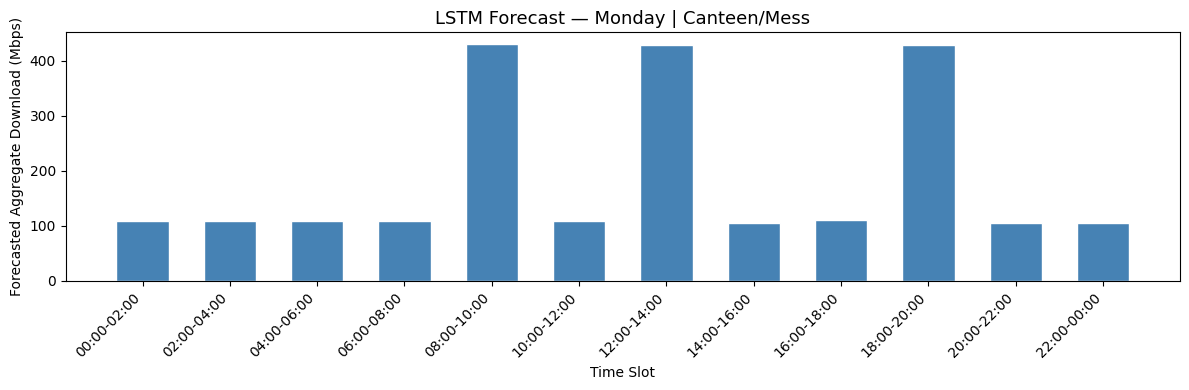


✅ Done! Change FORECAST_DAY or FORECAST_LOCATION above and re-run Cell 15.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cell 15 — Future Forecast: pick a Day → get all 12 time slots
#            for every location
# ─────────────────────────────────────────────────────────────────

# ── CONFIG: change these two lines ────────────────────────────
FORECAST_DAY      = "Monday"    # Monday / Tuesday / … / Sunday
FORECAST_LOCATION = "Canteen/Mess"   # or "All" to see every location
# ──────────────────────────────────────────────────────────────

TIME_SLOTS = [
    "00:00-02:00", "02:00-04:00", "04:00-06:00", "06:00-08:00",
    "08:00-10:00", "10:00-12:00", "12:00-14:00", "14:00-16:00",
    "16:00-18:00", "18:00-20:00", "20:00-22:00", "22:00-00:00",
]
SLOT_HOURS = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]

DAY_ORDER  = ["Monday","Tuesday","Wednesday","Thursday",
              "Friday","Saturday","Sunday"]
DOW_MAP    = {d: i for i, d in enumerate(DAY_ORDER)}

def forecast_day_for_location(loc_name, day_name):
    """
    Uses the trained model for `loc_name` to predict all 12 time slots
    of `day_name` by rolling the last SEQ_LEN known values forward.
    """
    loc_df2 = df[df["Location"] == loc_name].copy().reset_index(drop=True)
    loc_df2["hour_sin"]   = np.sin(2 * np.pi * loc_df2["Hour"] / 24)
    loc_df2["hour_cos"]   = np.cos(2 * np.pi * loc_df2["Hour"] / 24)
    loc_df2["dow2"]       = loc_df2["DateTime"].dt.dayofweek
    loc_df2["dow_sin"]    = np.sin(2 * np.pi * loc_df2["dow2"] / 7)
    loc_df2["dow_cos"]    = np.cos(2 * np.pi * loc_df2["dow2"] / 7)
    loc_df2["is_weekend"] = (loc_df2["dow2"] >= 5).astype(int)

    data2      = loc_df2[feature_cols_base].values
    n_feat2    = data2.shape[1]

    scaler2    = MinMaxScaler()
    data_sc2   = scaler2.fit_transform(data2)

    # retrain a fresh model on this location
    X2, y2     = make_sequences(data_sc2, SEQ_LEN)
    split2     = int(len(X2) * TRAIN_FRACTION)
    m2         = build_lstm(SEQ_LEN, n_feat2)
    es2        = EarlyStopping(monitor="val_loss", patience=8,
                               restore_best_weights=True)
    m2.fit(X2[:split2], y2[:split2],
           validation_split=0.15, epochs=100,
           batch_size=32, callbacks=[es2], verbose=0)

    # ── rolling forecast for all 12 slots of the chosen day ──
    dow_val    = DOW_MAP[day_name]
    window     = data_sc2[-SEQ_LEN:].copy()   # last SEQ_LEN real rows
    predictions = []

    for slot_h in SLOT_HOURS:
        # build a synthetic feature row for this future slot
        h_sin = np.sin(2 * np.pi * slot_h / 24)
        h_cos = np.cos(2 * np.pi * slot_h / 24)
        d_sin = np.sin(2 * np.pi * dow_val / 7)
        d_cos = np.cos(2 * np.pi * dow_val / 7)
        is_we = 1 if dow_val >= 5 else 0

        inp   = window.reshape(1, SEQ_LEN, n_feat2)
        pred_sc = m2.predict(inp, verbose=0).flatten()[0]

        # inverse transform the predicted bandwidth
        dummy           = np.zeros((1, n_feat2))
        dummy[0, 0]     = pred_sc
        pred_real       = scaler2.inverse_transform(dummy)[0, 0]
        predictions.append(round(pred_real, 2))

        # build next window row: use predicted bandwidth + engineered features
        # for remaining features use the mean of training data (reasonable proxy)
        mean_row        = data_sc2.mean(axis=0).copy()
        mean_row[0]     = pred_sc          # predicted bandwidth (scaled)
        mean_row[5]     = h_sin            # hour_sin  (index 5 in feature_cols)
        mean_row[6]     = h_cos            # hour_cos
        mean_row[7]     = d_sin            # dow_sin
        mean_row[8]     = d_cos            # dow_cos
        mean_row[9]     = is_we            # is_weekend
        window          = np.vstack([window[1:], mean_row])

    return predictions


# ── run forecast ───────────────────────────────────────────────
if FORECAST_LOCATION == "All":
    target_locs = list(df["Location"].unique())
else:
    target_locs = [FORECAST_LOCATION]

forecast_records = []

for floc in target_locs:
    print(f"\n⏳ Forecasting {FORECAST_DAY} — {floc} ...")
    preds = forecast_day_for_location(floc, FORECAST_DAY)
    for slot, pred in zip(TIME_SLOTS, preds):
        forecast_records.append({
            "Location"              : floc,
            "Day"                   : FORECAST_DAY,
            "Time_Slot"             : slot,
            "Forecasted_Mbps"       : pred,
        })

forecast_df = pd.DataFrame(forecast_records)

# ── display ────────────────────────────────────────────────────
print("\n")
print("=" * 65)
print(f"  📅 LSTM Forecast — {FORECAST_DAY}  |  Location: {FORECAST_LOCATION}")
print("=" * 65)
print(forecast_df.to_string(index=False))
print("=" * 65)

# ── plot ───────────────────────────────────────────────────────
for floc in target_locs:
    sub = forecast_df[forecast_df["Location"] == floc]
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(TIME_SLOTS)), sub["Forecasted_Mbps"].values,
            color="steelblue", edgecolor="white", width=0.6)
    plt.xticks(range(len(TIME_SLOTS)), TIME_SLOTS, rotation=45, ha="right")
    plt.title(f"LSTM Forecast — {FORECAST_DAY} | {floc}", fontsize=13)
    plt.xlabel("Time Slot")
    plt.ylabel("Forecasted Aggregate Download (Mbps)")
    plt.tight_layout()
    plt.show()

print("\n✅ Done! Change FORECAST_DAY or FORECAST_LOCATION above and re-run Cell 15.")